In [6]:
import nextnanopy as nn
import os
import matplotlib.pyplot as plt
import numpy as np
import sys


In [7]:
path_nextnanoprojects_tools = r"C:\Users\sp6497_a\nextnanopy_projects"

In [8]:
print(sys.path)
sys.path.append(path_nextnanoprojects_tools)
print(sys.path)
from nextnano_tools.helper_functions import build_output, plot_ldos
from nextnano_tools.simstructs import SimOut, BandStructure, Eigenstate

['c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\python313.zip', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\DLLs', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev', '', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib\\site-packages', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib\\site-packages\\win32', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib\\site-packages\\win32\\lib', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib\\site-packages\\Pythonwin', 'C:\\Users\\sp6497_a\\nextnanopy_projects']
['c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\python313.zip', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\DLLs', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev', '', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib\\site-packages', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib\\site

In [9]:
bias = r'bias_00000'
quantum_region = r'Quantum\quantum_region'
quantum_band = r'Gamma'
quantum_band_interactions = r'Gamma_Gamma'

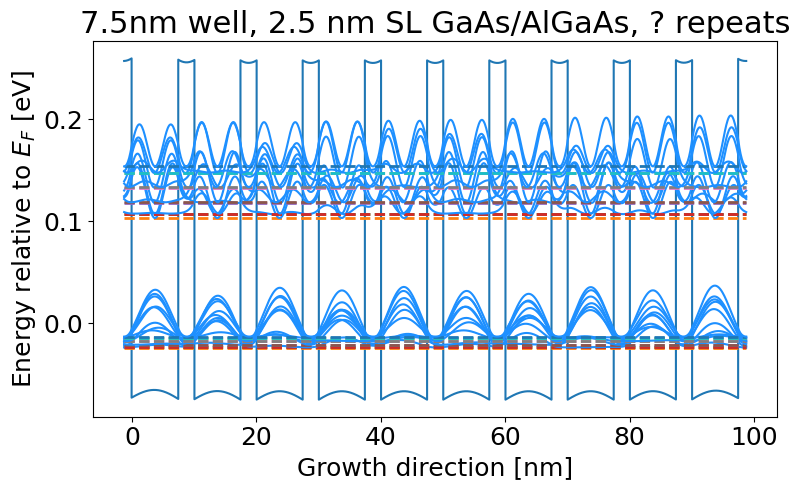


Intersubband transition energies — Gamma
-----------------------------------------------------
 i → j | ΔE (eV)
-----------------------------------------------------
  4 →  5 | -0.0001
  2 →  3 | -0.0001
  6 →  7 | -0.0001
  8 →  9 | -0.0002
 18 → 19 | -0.0004
 12 → 13 | -0.0005
 16 → 17 | -0.0006
 14 → 15 | -0.0006
  1 →  2 | -0.0009
  1 →  3 | -0.0010
  9 → 10 | -0.0013
  8 → 10 | -0.0015
  3 →  4 | -0.0025
  3 →  5 | -0.0026
  2 →  4 | -0.0026
  2 →  5 | -0.0027
  7 →  8 | -0.0030
  6 →  8 | -0.0031
  7 →  9 | -0.0032
  6 →  9 | -0.0033
  5 →  6 | -0.0034
  4 →  6 | -0.0035
  1 →  4 | -0.0035
  5 →  7 | -0.0035
  1 →  5 | -0.0036
  4 →  7 | -0.0036
 11 → 12 | -0.0038
 11 → 13 | -0.0043
  7 → 10 | -0.0045
  6 → 10 | -0.0046
  3 →  6 | -0.0060
 19 → 20 | -0.0061
  2 →  6 | -0.0061
  3 →  7 | -0.0061
  2 →  7 | -0.0062
 18 → 20 | -0.0064
  5 →  8 | -0.0066
  4 →  8 | -0.0066
  5 →  9 | -0.0068
  4 →  9 | -0.0068
  1 →  6 | -0.0070
  1 →  7 | -0.0071
  5 → 10 | -0.0080
  4 → 10 | -0.00

In [10]:
# %matplotlib widget
parent_dir = r"C:\Users\sp6497_a\OneDrive - Princeton University\nextnano_outs\Output\manual_build_array_x(15)"
# parent_dir = r"C:\Users\sp6497_a\OneDrive - Princeton University\nextnano_outs\Output\1Dsuperlattice_5nm_well_Nsweep_nnp(4)"
# parent_dir = r"C:\Users\sp6497_a\OneDrive - Princeton University\nextnano_outs\Output\confirming_dipole_matrix_elements_expected(6)"

# VB_cutoff = -1.0
simoutidk = build_output(parent_dir,quantum_region,bias,14,model='1band')
simoutidk.bands['Gamma'].sort_subbands(decreasing=False)

simoutidk.bands['Gamma'].plot_band(title_diff='7.5nm well, 2.5 nm SL GaAs/AlGaAs, ? repeats',show_legend=False)
# simoutidk.bands['CB'].plot_band(title_diff='10nm SW GaAs/AlGaAs',normalize_y=False,show_legend=True)
simoutidk.bands['Gamma'].calc_intersubband_transitions()
simoutidk.bands['Gamma'].display_intersubband_transitions(upward_only=True,sort_by_deltaE="descending")


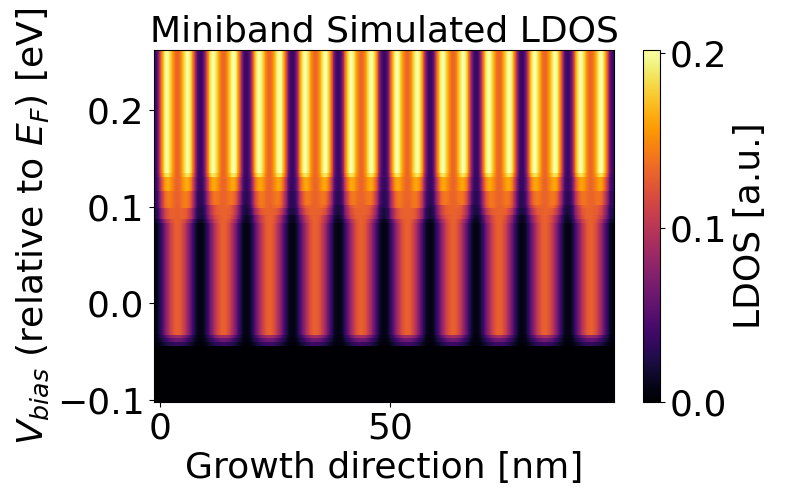

In [20]:
%matplotlib widget
ldos_fig,ldos_ax = plt.subplots(figsize=(8,5))
basefont = 26
eVbias = np.linspace(-0.1, 0.26, 100)
Vmod = 0.01 #V 
Ebroad = Vmod*1.8
ldos = simoutidk.bands['Gamma'].calc_ldos(eVbias,deltaE=Ebroad)
# plot_ldos(simoutidk.bands['CB'], ldos, eVbias,title_diff=r'LDOS cumulative $\sum^{E_n <=eV_{bias}} {|\Psi_n|}^2$')
# alt_title = rf'LDOS cumulative $\sum^{{E_n \leq eV_{{bias}}}} {{|\Psi_n|}}^2$, $V_{{mod}}={Vmod*1000:.0f}$ $mV_{{pp}}$, $\delta E={Ebroad*1000:.0f}$ mV'
poster_title = 'Miniband Simulated LDOS'
plot_ldos(simoutidk.bands['Gamma'], ldos, eVbias,ax=ldos_ax,title_diff=poster_title,show=False,fontsizetitle=basefont,fontsizebase=basefont)
ldos_ax.set_ylabel('$V_{bias}$ (relative to $E_{F})$ [eV]',fontsize=basefont)
plt.tight_layout()


In [ ]:
eVbias
summed_probabdist = np.zeros_like(simoutidk.bands['CB'].subbands[0].probab_dist)
for subbands in simoutidk.bands['CB'].subbands:
    summed_probabdist += subbands.probab_dist

plt.plot(simoutidk.bands['CB'].x, summed_probabdist)

In [ ]:
simoutidk.bands['CB'].subbands